In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Dataset/diabetes.csv')

_**Dataset Exploration**_

In [3]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Interesting there is not null value but there are 0 in the values that act like hiden nulls

In [7]:
df.head(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1


In [8]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {col:30s}: {zeros:3d} zeros ({pct:.1f}%)")

  Glucose                       :   5 zeros (0.7%)
  BloodPressure                 :  35 zeros (4.6%)
  SkinThickness                 : 227 zeros (29.6%)
  Insulin                       : 374 zeros (48.7%)
  BMI                           :  11 zeros (1.4%)


There are multiple 0 in the columns, Conversion is needed for pandas to handle them properly.

In [9]:
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


_**Visualization**_

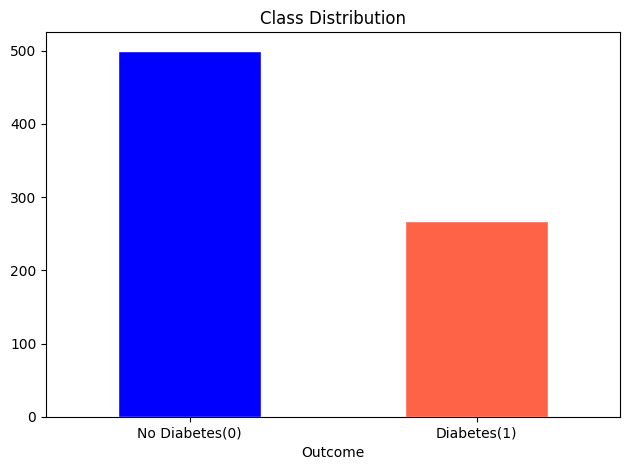

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

In [11]:
# What is the class distribution of diabetic and non diabetic?
ax = df['Outcome'].value_counts().plot(kind='bar', color=['blue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['No Diabetes(0)', 'Diabetes(1)'], rotation=0)
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

df['Outcome'].value_counts(normalize=True).round(3)

The majority are non-diabetic.It is a 65/35 split of data.

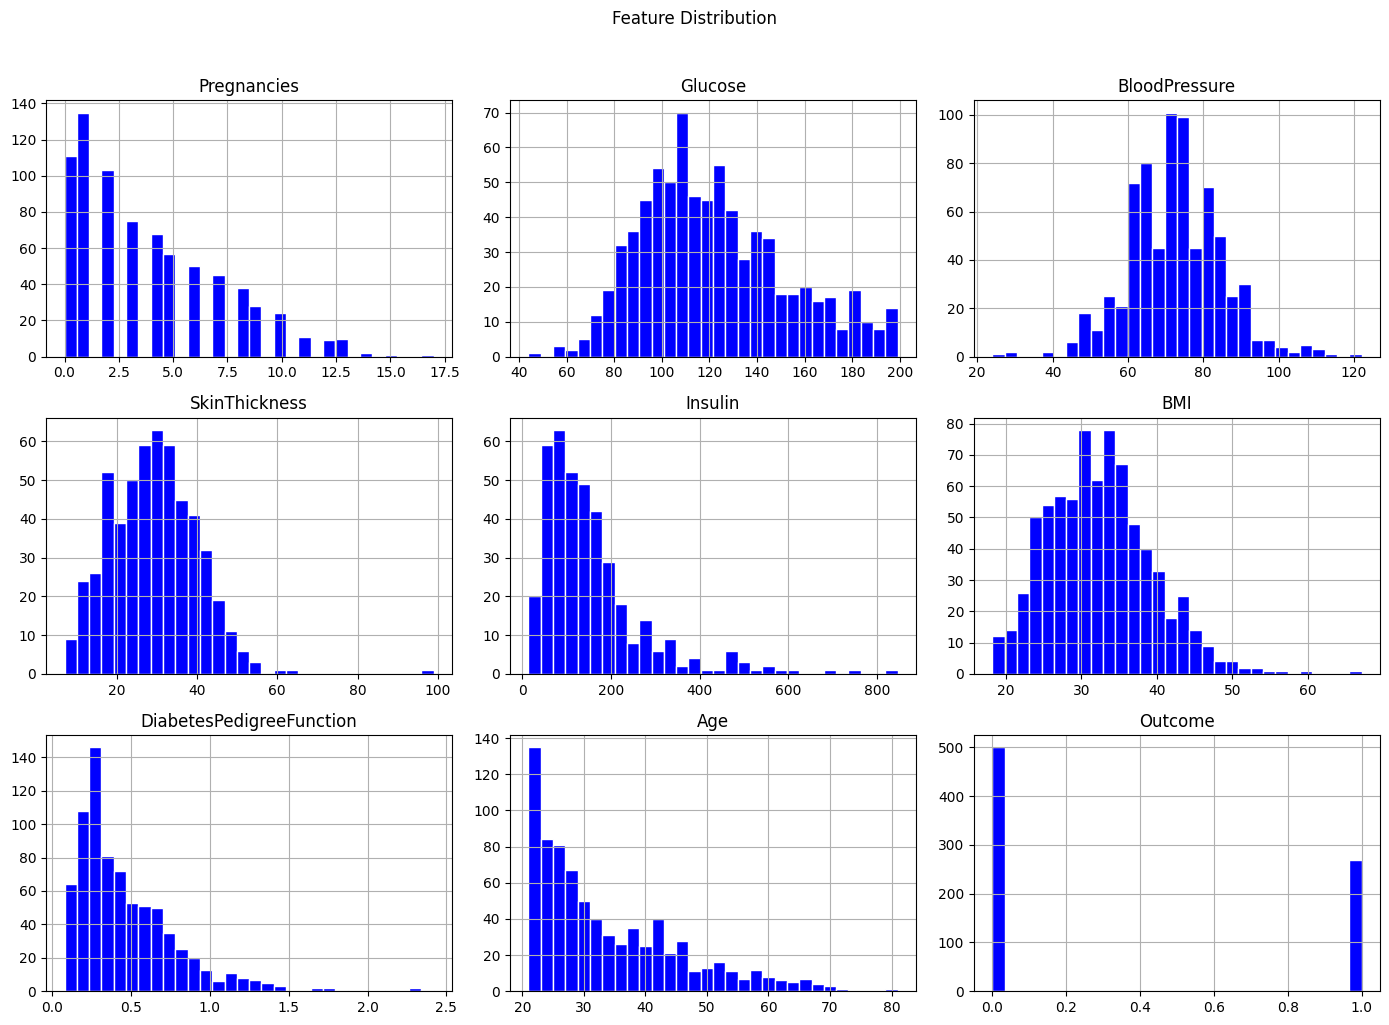

In [12]:
#What would each feature look like? 
df.hist(figsize=(14,10), bins=30, color='blue', edgecolor='white')
plt.suptitle('Feature Distribution', y=1.02)
plt.tight_layout()
plt.show()

Glucose has the most well balanced shape

Insulin has a massive spike at 0 followed by a long right tail which confirms the missing values found earier.

Pregnancies and Age are right skewed, most patients are young with fewer pregnancies

SkinThickness has that suspicious spike at 0 confirming the missing values

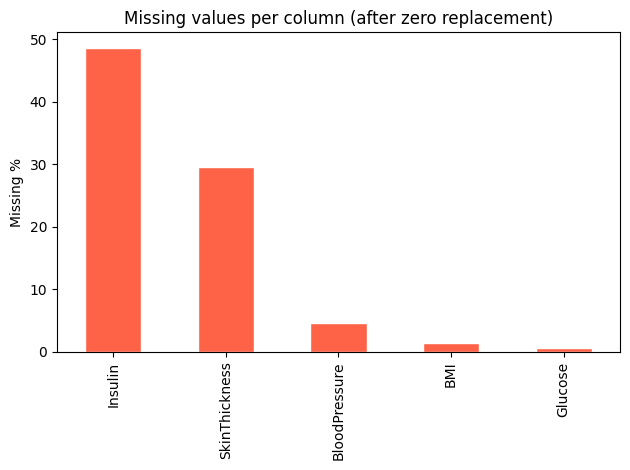

In [13]:
#What does my null value columns look like?
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind='bar', color='tomato', edgecolor='white')
plt.ylabel('Missing %')
plt.title('Missing values per column (after zero replacement)')
plt.tight_layout()
plt.show()

Insulin ~49% and SkinThickness ~30% are the problem columns. BloodPressure, BMI, Glucose are minor in comparison.

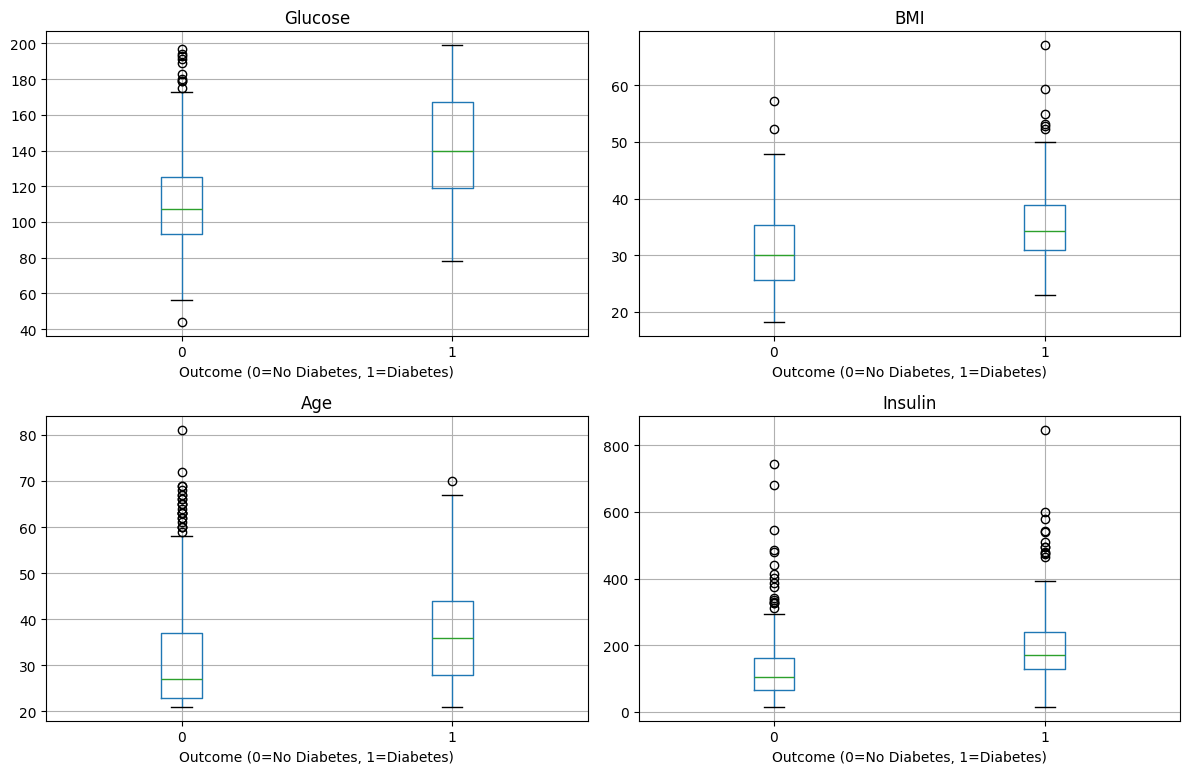

In [14]:
# what will the box plot look like for glucose, age, bmi, insulin?
features = ['Glucose', 'BMI', 'Age', 'Insulin']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), features):
    df.boxplot(column=col, by='Outcome', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.suptitle('')
plt.tight_layout()
plt.show()

Glucose shows the biggest separation between 0 and 1, diabetic patients have clearly higher glucose

BMI also separates well, diabetics tend to have higher BMI

Age separates moderately, diabetics tend to be older

Insulin has massive outliers, confirms clipping is needed

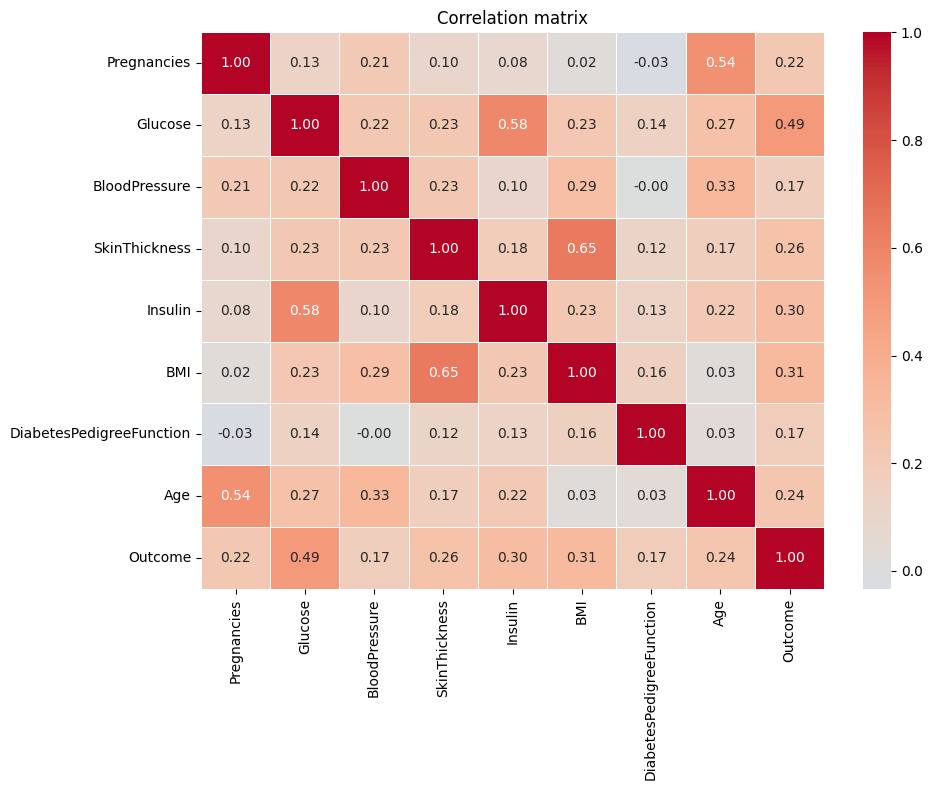

In [15]:
#What will the correlation look like?
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

Glucose has the highest correlation with Outcome at 0.49. BMI (0.31), Age (0.24), and Pregnancies (0.22) follow. BloodPressure has almost no correlation (0.17).

Feature engineering is required as Glucose or BMI alone will not be predict accurately

_**Data Pre-processing**_

Missing values fillup

In [16]:
cols_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

In [17]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Cliping outliers

In [19]:
# Insulin
df['Insulin'] = df['Insulin'].clip(upper=df['Insulin'].quantile(0.99))
# BMI
df['BMI'] = df['BMI'].clip(upper=df['BMI'].quantile(0.99))
# SkinThickness
df['SkinThickness'] = df['SkinThickness'].clip(upper=df['SkinThickness'].quantile(0.99))

In [20]:
df[['Insulin', 'BMI', 'SkinThickness']].describe().round(2)

,Insulin,BMI,SkinThickness
count,768.00,768.00,768.00
mean,139.48,32.40,29.00
std,79.38,6.68,8.33
min,14.00,18.20,7.00
25%,121.50,27.50,25.00
50%,125.00,32.30,29.00
75%,127.25,36.60,32.00
max,519.90,50.76,51.33


_**Feature Engineering**_

Both combined create a strong feature for the model to base it's predict on

In [21]:
df['glucose_bmi'] = df['Glucose'] * df['BMI']

age_risk is created to give the model an edge for the predicting process, it can still learn from the values but this gives it a shortcut.

It is done as it is seen that older females tend to be more diabetic

In [22]:
df['age_risk'] = (df['Age'] >= 45 ).astype(int)

In [23]:
df[['glucose_bmi', 'age_risk']].describe().round(2)

,glucose_bmi,age_risk
count,768.00,768.00
mean,3988.93,0.17
std,1448.94,0.38
min,1100.00,0.00
25%,2924.10,0.00
50%,3750.15,0.00
75%,4780.35,0.00
max,9136.62,1.00


In [24]:
df['age_risk'].value_counts()

age_risk
0    635
1    133
Name: count, dtype: int64

_**Spliting The Data**_

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
# X and Y seperation
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

# Train and test split
X_train, X_test , Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [27]:
X_all = X.copy()
Y_all = Y.copy()

Scaled Data

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("Diabetic rate (train):", round(Y_train.mean(), 3))
print("Diabetic rate (test): ", round(Y_test.mean(), 3))

Train shape: (614, 10)
Test shape:  (154, 10)
Diabetic rate (train): 0.349
Diabetic rate (test):  0.351


_**Model Traning and Testing**_

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

Model-1: Logistic Regression

In [32]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train_scaled, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [33]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]


print(classification_report(Y_test, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))
print("ROC-AUC:", round(roc_auc_score(Y_test, y_prob_lr), 4))

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
                        max_iter=1000, 
                        random_state=42, 
                        class_weight='balanced'
    ))])
lr_scores = cross_val_score(lr_pipe, X_all, Y_all, cv=5, scoring='roc_auc')
print(f"Cross validation — fold scores: {[round(s,4) for s in lr_scores]}")
print(f"Mean AUC: {lr_scores.mean():.4f}  Std: {lr_scores.std():.4f}")

# ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_lr, display_labels=['No Diabetes', 'Diabetes'])
# plt.title('Confusion Matrix — Logistic Regression')
# plt.show()

              precision    recall  f1-score   support

 No Diabetes       0.84      0.76      0.80       100
    Diabetes       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

ROC-AUC: 0.8139
Cross validation — fold scores: [np.float64(0.8169), np.float64(0.8024), np.float64(0.8431), np.float64(0.8813), np.float64(0.8442)]
Mean AUC: 0.8376  Std: 0.0270


Model-2: Decision Tree

In [34]:
dt = DecisionTreeClassifier(
    random_state=42, 
    class_weight='balanced', 
    max_depth=5
)
dt.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

              precision    recall  f1-score   support

 No Diabetes       0.82      0.62      0.70       100
    Diabetes       0.51      0.74      0.61        54

    accuracy                           0.66       154
   macro avg       0.66      0.68      0.66       154
weighted avg       0.71      0.66      0.67       154

ROC-AUC: 0.7515
Cross validation — fold scores: [np.float64(0.7463), np.float64(0.7465), np.float64(0.8214), np.float64(0.8129), np.float64(0.7656)]
Mean AUC: 0.7785  Std: 0.0324


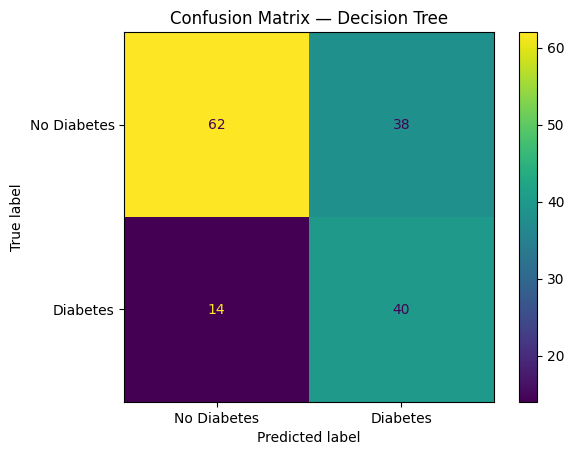

In [35]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(classification_report(Y_test, y_pred_dt, target_names=['No Diabetes', 'Diabetes']))
print("ROC-AUC:", round(roc_auc_score(Y_test, y_prob_dt), 4))

dt_scores = cross_val_score(dt, X_all, Y_all, cv=5, scoring='roc_auc')
print(f"Cross validation — fold scores: {[round(s,4) for s in dt_scores]}")
print(f"Mean AUC: {dt_scores.mean():.4f}  Std: {dt_scores.std():.4f}")


ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_dt, display_labels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Decision Tree')
plt.show()

Model-3: Random Forest

In [36]:
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)
rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

 No Diabetes       0.77      0.82      0.79       100
    Diabetes       0.62      0.54      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.68       154
weighted avg       0.71      0.72      0.72       154

ROC-AUC: 0.8185
Cross validation — fold scores: [np.float64(0.8138), np.float64(0.7757), np.float64(0.8376), np.float64(0.8934), np.float64(0.8048)]
Mean AUC: 0.8251  Std: 0.0395


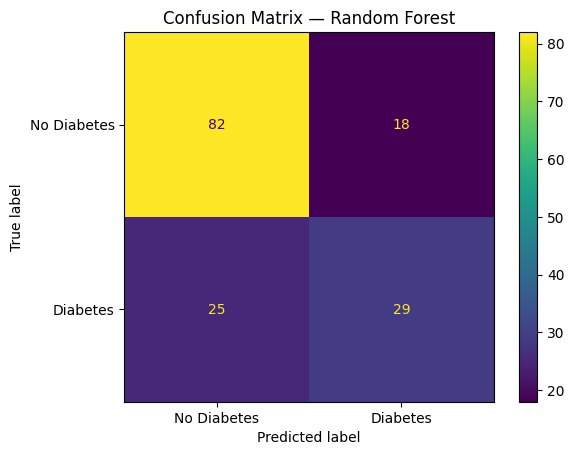

In [37]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(Y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))
print("ROC-AUC:", round(roc_auc_score(Y_test, y_prob_rf), 4))

rf_scores = cross_val_score(rf, X_all, Y_all, cv=5, scoring='roc_auc')
print(f"Cross validation — fold scores: {[round(s,4) for s in rf_scores]}")
print(f"Mean AUC: {rf_scores.mean():.4f}  Std: {rf_scores.std():.4f}")

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_rf, display_labels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — Random Forest')
plt.show()


Model-4: SVM

In [38]:
svm = SVC(
    probability=True, 
    class_weight='balanced', 
    random_state=42
)
svm.fit(X_train_scaled, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


              precision    recall  f1-score   support

 No Diabetes       0.84      0.73      0.78       100
    Diabetes       0.60      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.74       154

ROC-AUC: 0.8094
Cross validation — fold scores: [np.float64(0.797), np.float64(0.7933), np.float64(0.8372), np.float64(0.8798), np.float64(0.8457)]
Mean AUC: 0.8306  Std: 0.0323


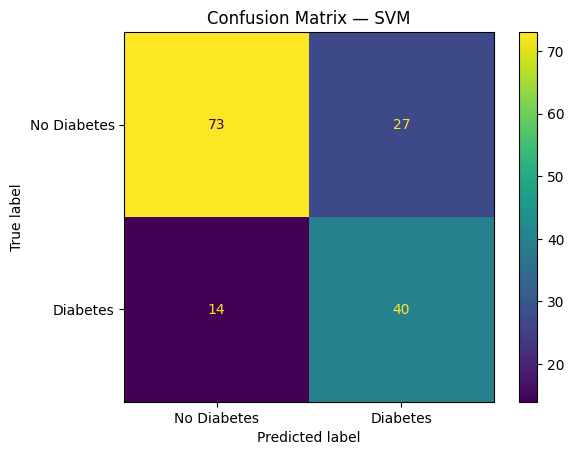

In [39]:
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

print(classification_report(Y_test, y_pred_svm, target_names=['No Diabetes', 'Diabetes']))
print("ROC-AUC:", round(roc_auc_score(Y_test, y_prob_svm), 4))

svm_pipe = Pipeline([('scaler', StandardScaler()),
                     ('model', SVC(
                                    probability=True, 
                                    class_weight='balanced', 
                                    random_state=42
                    ))])
svm_scores = cross_val_score(svm_pipe, X_all, Y_all, cv=5, scoring='roc_auc')
print(f"Cross validation — fold scores: {[round(s,4) for s in svm_scores]}")
print(f"Mean AUC: {svm_scores.mean():.4f}  Std: {svm_scores.std():.4f}")

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_svm, display_labels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — SVM')
plt.show()

Model-5: XGboost

In [40]:
# scale calcutalion
scale = round((Y_train == 0).sum() / (Y_train == 1).sum(), 2)
print(f"scale_pos_weight = {scale}")

scale_pos_weight = 1.87


In [41]:
xgb = XGBClassifier(
    n_estimators=100, 
    scale_pos_weight=scale,
    random_state=42, 
    eval_metric='logloss'
)
xgb.fit(X_train, Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

              precision    recall  f1-score   support

 No Diabetes       0.81      0.81      0.81       100
    Diabetes       0.65      0.65      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

ROC-AUC: 0.8039
Cross validation — fold scores: [np.float64(0.7657), np.float64(0.7604), np.float64(0.7763), np.float64(0.8691), np.float64(0.8017)]
Mean AUC: 0.7946  Std: 0.0398


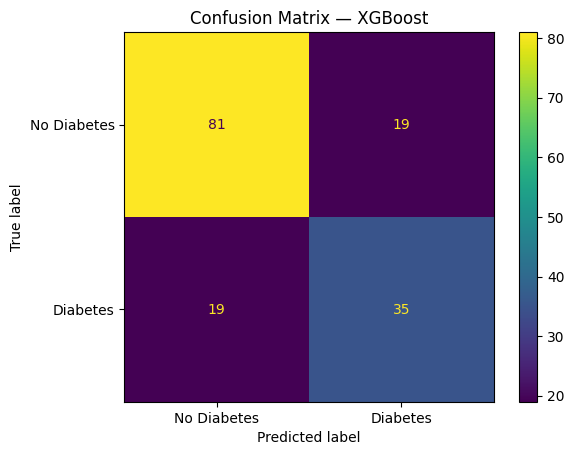

In [42]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(Y_test, y_pred_xgb, target_names=['No Diabetes', 'Diabetes']))
print("ROC-AUC:", round(roc_auc_score(Y_test, y_prob_xgb), 4))

xgb_scores = cross_val_score(xgb, X_all, Y_all, cv=5, scoring='roc_auc')
print(f"Cross validation — fold scores: {[round(s,4) for s in xgb_scores]}")
print(f"Mean AUC: {xgb_scores.mean():.4f}  Std: {xgb_scores.std():.4f}")

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_xgb, display_labels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix — XGBoost')
plt.show()

Logistic Regression achieved the highest cross validation mean AUC of 0.8376, which is the most reliable performance measure since it tests every row exactly once across five independent splits rather than relying on a single lucky split. Critically, it also had the lowest standard deviation of 0.0271, meaning it performed consistently across all five folds regardless of which rows it saw. It is a sign of genuine learning rather than overfitting to a particular subset. The dataset's correlation heatmap revealed mostly linear relationships between features like Glucose (0.49), BMI (0.31), and the Outcome, which is precisely the type of pattern Logistic Regression is mathematically designed to capture efficiently.

_**Best Model(Logistic Regression)**_

In [ ]:
import joblib

joblib.dump(lr, 'Model/diabetes_model.pkl')
joblib.dump(scale, 'Model/diabetes_scaler.pkl')